# Equations non-linéaires (2)

### Méthode de point fixe

Soit $g : \mathbb{R} \to \mathbb{R}$ une fonction. On considère le problème de point fixe $g(x) = x$. 

Sous certaines conditions la suite définie par 

$\quad x_{n+1} = g(x_n),\quad\quad n\geq 0$, 

avec $x_0$ un point initial donné, converge vers la solution du problème de point fixe. 

## Exercice 1 

a) Programmer la méthode de point fixe : 

1. Etant donnés $g$ une fonction, $x_0$ le point initial, $\varepsilon$ une tolérance et $N_{max}$ le nombre maximal d'itérations.

2. $k=0$, $err = \varepsilon + 1.$ (initialisation) 

3. tant que le critère d'arrêt n'est pas verifié, faire 
    
    $\quad\quad x_{k+1} = g(x_k)$
    
    $\quad\quad$ calculer $err$
    
    $\quad\quad k \leftarrow k+1$ 
    
    

$\quad$ fin (tant que)

4. Retourner $x_k$, $g(x_k)$, $k$ et $err$

On doit arrêter l'algorithme si 
$|x_k - x_{k-1}|< \varepsilon $ ou $k > Nmax$. 

On pourra compléter la fonction suivante : 

In [1]:
def pointfixe2(g, x0, tol, Nmax):
    err = 1. + tol #erreur initial
    k = 0
    xk = x0
    while err > tol and k<=Nmax : 
        xp = xk     #on garde l'itéré précédent.  
        xk = g(xk)  # xk itéré suivant    
        err = abs(xk-xp)  #  calcul de l'erreur 
        k = k+1
    #fin while
    return xl #[xk,g(xk),err,k] 
#fin pointfixe


b) Résoudre le problème de point fixe $\cos x = x$ avec la méthode de point fixe. 



In [2]:
import numpy as np
def g(x):
    y = np.cos(x)#= ...à compléter
    return y
#fin g

pointfixe(g,1,1e-8,100)

[0.7390851366465718, 0.7390851309037207, 8.525458006225506e-09, 46]

c) On considère $x\mapsto \phi(x) = \displaystyle\frac{3x^2}{1+x^2}$. Cette fonction admet trois points fixes. 
Tracer la fonction $\phi$ et la fonction $x\mapsto id(x) = x$ pour $0 \leq x \leq 5$. 
Peut-on calculer les trois points fixes de $\phi$ avec la méthode de point fixe ? Justifier. 



[2.6180339854591885, 2.6180339879119363, 9.632064923437156e-09, 22]

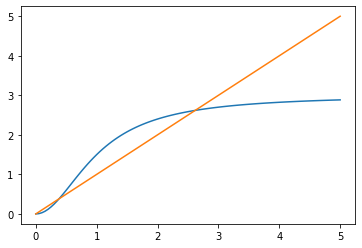

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def phi(x): 
    y = (3.*x**2)/(1+x**2) # ...à compléter
    return y
#fin phi

X = np.linspace(0,5,101)
Y = phi(X)


plt.plot(X,Y)
plt.plot(X,X)

pointfixe(phi,0.4,1e-8,100)

In [ ]:
# Sur le graphique, les trois points fixex sont les points d'intersection entre le graphe de phi et 
# la droite y=x. On les note x1, x2, x3.
# Du graphe on peut déduire que le point fixe x1 (proche de 0) et le point fixe x3 proche de 2,5 sont attractifs 
# (on voit que la pente des droites tangentes à phi en x1 et x3 sont entre 0 et 1). Le point fixe proche de 0,5 
# est repulsif (on voit que la pente de la droite tangente en  x1 est supérieur à 1). La méthode de point fixe 
# ne peut pas être utilisée pour calculer  x2.

d) Modifier la fonction 
 avec la méthode de point fixe afin qu'elle retourne un tableau avec tous 
les termes $x_k$. 
Calculer les erreurs 
 
 $\quad e_k = |x_k - \alpha|, \quad k\geq 0$,

 avec $\alpha$ le point fixe "exacte" de $\cos(x)$ (i.e. la solution de $x- \cos(x) = 0$, calculée par exemple avec bissection et une tolérance très petite).
 
Calculer un tableau avec les quotients $e_{k+1}/e_k$. Tracer $e_{k+1}/e_k$  en fonction de $k$. Interpreter. 


In [4]:
def pointfixe2(g, x0, tol, Nmax):
    err = 1. + tol #erreur initial
    k = 0
    xk = []    # xk est une liste
    xk.append(x0)
    while err > tol and k<=Nmax : 
        xk.append(g(xk[k])) 
        err = abs(xk[k+1]-xk[k])
        k=k+1
    #fin while
    return xk 
#fin pointfixe2

# fonction bissection pour calculer la solution 'exacte'
def bissection(f, a, b, tol, N):
    k = 0                 # initialisation compteur
    err = (b-a)*0.5       # initialisation borne erreur
    if f(a)*f(b) > 0:
        print("Problème : f ne change pas de signe dans l'intervalle [a,b]")    
        return 0
    while err >= tol and k <= N: 
        xm = (a+b)*0.5
        if f(xm) == 0.0:
            print("Solution trouvée, itération k = ", k)
            break
        if f(xm)*f(a) < 0:
            b = xm
        if f(xm)*f(b) < 0:
            a = xm
        k=k+1
        err = (b-a)*0.5
        #print(xm,err)
    if k > N:
        print("nombre maximal d'itérations atteint : pas de convergence")
    return [xm,f(xm),err,k]
# fin fonction bissection 

def f(x): 
    y = np.cos(x) - x 
    return y
#fin 

res1 = bissection(f,0,1,1e-14,100)
xex= res1[0]
#print(type(xex))
x=pointfixe2(g,1,1e-8,100) # x est la liste avec les itérés calculés par pointfixe2
#err =abs(x-xex)
err =abs(np.array(x)-xex)  # avec np.array on transforme la liste en array pour faire les calculs 
rat = err[1:len(err)]/err[0:len(err)-1]  # on calcule les quotients

print("erreurs = ")
print(err)
print("quotients e_k+1/e_k = ")
print(rat)
print("g'(xex) = sin(xex) = ", np.sin(xex))

erreurs = 
[2.60914867e-01 1.98782827e-01 1.18468083e-01 8.47953427e-02
 5.43952255e-02 3.77163596e-02 2.48745497e-02 1.69827082e-02
 1.13326285e-02 7.68109079e-03 5.15222169e-03 3.48039278e-03
 2.33995339e-03 1.57824270e-03 1.06220235e-03 7.15929093e-04
 4.82068997e-04 3.24813341e-04 2.18759182e-04 1.47376500e-04
 9.92665563e-05 6.68707878e-05 4.50433145e-05 3.03424683e-05
 2.04387114e-05 1.37679162e-05 9.27416392e-06 6.24722018e-06
 4.20818822e-06 2.83469277e-06 1.90948016e-06 1.28625017e-06
 8.66432960e-07 5.83639957e-07 3.93146755e-07 2.64828456e-07
 1.78391592e-07 1.20166749e-07 8.09457473e-08 5.45260468e-08
 3.67293846e-08 2.47413711e-08 1.66660696e-08 1.12264804e-08
 7.56227692e-09 5.09405595e-09 3.43140205e-09]
quotients e_k+1/e_k = 
[0.76186854 0.59596739 0.7157653  0.64148836 0.69337629 0.65951619
 0.6827343  0.66730397 0.67778545 0.67076693 0.67551301 0.67232452
 0.67447613 0.67302852 0.67400443 0.67334741 0.67379015 0.67349198
 0.67369286 0.67355756 0.67364871 0.67358732 0.

In [ ]:
# on voit que les quotients tends vers une valeur constante C ~0,6736.... La méthode est d'ordre 1
# on vérifie aussi que la constante C correspond à g'(r) où r est le point fixe (r=xex).

### Méthode de Newton

Soit $f : I\mapsto \mathbb{R}$ un fonction deux fois dérivable sur I, un intervalle de $\mathbb{R}$. On suppose que 
l'équation $f(x) = 0$ admet une solution $\alpha$ dans $I$. Soit $x_0 \in I$ un point initial. La méthode de Newton 
consiste à construire la suite $\{x_k\}_{k\ge 0}$ en partant de $x_0$ définie par 

$\quad x_{k+1} =  x_k - \displaystyle\frac{f(x_k)}{f'(x_k)},\quad k\ge 0$,

avec $f'(x_k)\neq 0$.

Sous certains hypothèses la suite des itérés successifs $\{x_k\}$ converge vers la solution $\alpha$.

L'algorithme de la m\'ethode de Newton est 

1. Etant données $f$ et $f'$ (la fonction et sa dérivée), $x_0$ (le point initial), $\varepsilon$ (une tolérance), 
$Nmax$ (le nombre maximal d'itérations)

2. $k=0$, $err=1 + \varepsilon$  (initialisation).

3. tant que le critère d'arrêt n'est pas verifié, faire

$\quad\quad x_{k+1} = x_k - \displaystyle\frac{f(x_k)}{f'(x_k)}$.

$\quad\quad$Calculer $err$ 

$\quad\quad k \leftarrow k+1$ 

$\quad$fin (tant que)

4. Retourner $x_k$, $f(x_k)$, $k$ et $err$

On doit arrêter l'algorithme si 
$|x_k - x_{k-1}|< \varepsilon $ ou $k > Nmax$. 

a) Compléter le programme ci-dessous : 

In [5]:
def newton(f, df, x0, tol, Nmax):
    # f fonction, df dérivée de f
    err = 1. #erreur initial
    k = 0
    xp = x0;  
    while err > tol and k<=Nmax : 
        xk = xp - f(xp)/df(xp)
        err = abs(xk-xp)
        xp = xk
        k=k+1
    #fin while
    return [xk,f(xk),err,k] 
#fin newton

b) Résoudre avec la méthode de Newton $f(x) = 0$ avec  $f(x) = \cos(x) -x$. 


In [6]:
def f(x): 
    y = np.cos(x) - x # à compléter
    return y
#fin 

def df(x):
    y = -np.sin(x) - 1.
    return y

res= newton(f,df,1,1e-8,100)
print(res)
print("solution calculée xc = ", res[0], "f(xc) = ", res[1])
print("err calculée = ", res[2], " nombre d'itérations =", res[3])

[0.7390851332151607, 0.0, 1.7012335984389892e-10, 4]
solution calculée xc =  0.7390851332151607 f(xc) =  0.0
err calculée =  1.7012335984389892e-10  nombre d'itérations = 4


c) Pour une tolérance fixe, comparer le nombre d'itérations éffectuées avec 
dichotomie, secante, point fixe et Newton .



In [7]:
def bissection(f, a, b, tol, N):
    k = 0                 # initialisation compteur
    err = (b-a)*0.5       # initialisation borne erreur
    if f(a)*f(b) > 0:
        print("Problème : f ne change pas de signe dans l'intervalle [a,b]")    
        return 0
    while err >= tol and k <= N: 
        xm = (a+b)*0.5
        if f(xm) == 0.0:
            print("Solution trouvée, itération k = ", k)
            break
        if f(xm)*f(a) < 0:
            b = xm
        if f(xm)*f(b) < 0:
            a = xm
        k=k+1
        err = (b-a)*0.5
        #print(xm,err)
    if k > N:
        print("nombre maximal d'itérations atteint : pas de convergence")
    return [xm,f(xm),err,k]

# fin fonction bissection 

def secante(f, a, b, tol, N):
    k = 0                 # initialisation compteur
    err = (b-a)           # initialisation borne erreur
    while err >= tol and k <= N : 
        y2 = f(a)
        y1 = f(b)
        xs = b*y2/(y2-y1) + a*y1/(y1-y2)
        if f(xs) == 0.:
            print("solution trouvée")
            break
        b = a
        a = xs
        k=k+1
        err = abs(b-a)
        #print(k,xs, err)
    if k > N:
        print("nombre maximal d'itérations atteint : pas de convergence")
    #print(k,xs, err)
    return [xs,f(xs),err,k]

res1 = bissection(f,0,1,1e-8,100)
res2 = secante(f,0,1,1e-8,100)
res3 = pointfixe(g,1,1e-8,100)
res4 = newton(f,df,1,1e-8,100)


print("bissection : err = ", res1[2], " k = ", res1[3] )
print("secante    : err = ", res2[2], " k = ", res2[3] )
print("point fixe : err = ", res3[2], " k = ", res3[3] )
print("newton     : err = ", res4[2], " k = ", res4[3] )

bissection : err =  7.450580596923828e-09  k =  26
secante    : err =  1.6396439761479087e-11  k =  6
point fixe : err =  8.525458006225506e-09  k =  46
newton     : err =  1.7012335984389892e-10  k =  4


d) On considère l'équation $e^x -2 = 0$. Modifier la fonction 
 avec la méthode de Newton afin qu'elle retourne un tableau avec tous 
les itérés $x_k$. 
Calculer un tableau avec les erreurs 

$\quad e_k = |x_k - \alpha|, \quad k\geq 0$,

avec $\alpha$ la  solution "exacte" de $e^x -2 = 0$. 

Calculer deux tableaux avec les quotients $e_{k+1}/e_k$ et $e_{k+1}/e_k^2$. Tracer $e_{k+1}/e_k$  et $e_{k+1}/e_k^2$ en fonction de $k$. Interpréter. 

In [8]:
def f(x): 
    y = np.exp(x) - 2.# à compléter
    return y
#fin 

def df(x): 
    y = np.exp(x) # à compléter
    return y
#fin 



def newton2(f, df, x0, tol, Nmax):
    # f fonction, df dérivée de f
    xk = []  # déclaration liste 
    err = 1. #erreur initial
    k = 0
    xk.append(x0)
    while err > tol and k<=Nmax : 
        xp = xk[k]
        xk.append(xp - f(xp)/df(xp))
        err = abs(xk[k+1]-xk[k])
        k=k+1         
    #fin while
    return xk 
#fin newton2

print(np.log(2))
newton(f,df,1,1e-12,100)
x=newton2(f,df,1,1e-12,100)
print("itérés Newton x = ", x)
# type(x)

0.6931471805599453
itérés Newton x =  [1, 0.7357588823428847, 0.6940422999189153, 0.6931475810597714, 0.6931471805600254, 0.6931471805599453]


In [14]:
err = abs(x-np.log(2)) # calcul de l'erreur
type(err)

numpy.ndarray

In [15]:
# calcul quotients
r = err[1:len(err)]/err[0:len(err)-1]
r2 = err[1:len(err)]/err[0:len(err)-1]**2

In [16]:
print("quotient e_k+1/e_k = ")
print(r)
print("quotient e_k+1/e_k^2 = ")
print(r2)

quotient e_k+1/e_k = 
[1.38866906e-01 2.10064213e-02 4.47426170e-04 2.00145162e-07
 0.00000000e+00]
quotient e_k+1/e_k^2 = 
[0.45255216 0.49297307 0.49985085 0.49973845 0.        ]


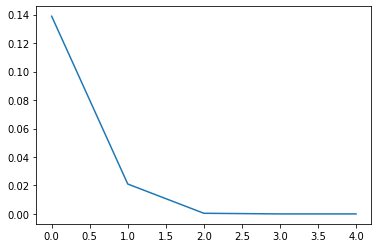

In [17]:
plt.plot(r)

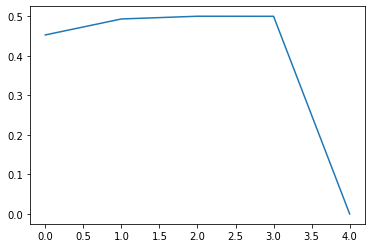

In [18]:
plt.plot(r2)